In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
# from fastlisaresponse import ResponseWrapper
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
from lisatools.sensitivity import get_sensitivity,CornishLISASens
import pandas as pd
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path


startup
Not on GPU


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable',
                      noise_model=get_sensitivity,
                      noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                      channels=["A","E"])

In [3]:
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.4
xI0 = 1.0
dist = 0.5
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3
Phi_phi0 = 0.5
Phi_theta0 =0.5
Phi_r0 = 0.5

dt = 10.0
T = 0.3

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

#param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev1p','dev1e'] #works
#rhvae to take qK and phiK constant for it to run
#'Phi_phi0',"Phi_theta0",'Phi_r0' derivatives are present analytically it says

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)


wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7.0, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.5, 0.5, 0.5, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


np.float64(48.19154944940133)

T:  0.3 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7.0, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.5, 0.5, 0.5, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 48.19154944940133
calculating stable deltas...
Gamma_ii for m1: 83.65021948974564
Gamma_ii for m1: 83.6502303468673
Gamma_ii for m1: 83.65028200772919
Gamma_ii for m1: 83.65017833957799
Gamma_ii for m1: 83.64915816212698
Gamma_ii for m1: 83.65269793696622
Gamma_ii for m1: 83.64034464600019
Gamma_ii for m1: 83.67941576856536
Gamma_ii for m1: 83.68477050532324
Gamma_ii for m1: 83.42500468717358
Gamma_ii for m1: 82.98315990881432
Gamma_ii for m1: 84.19867244984003
[np.float64(1.2979189203290568e-07), np.float64(6.175814431858743e-07), np.float64(1.2393058001242475e-06), np.float64(1.219590816483185e-05), np.float64(4.231513061189159e-05), np.float64(0.00014769536182947105), np.float64(0.0004669

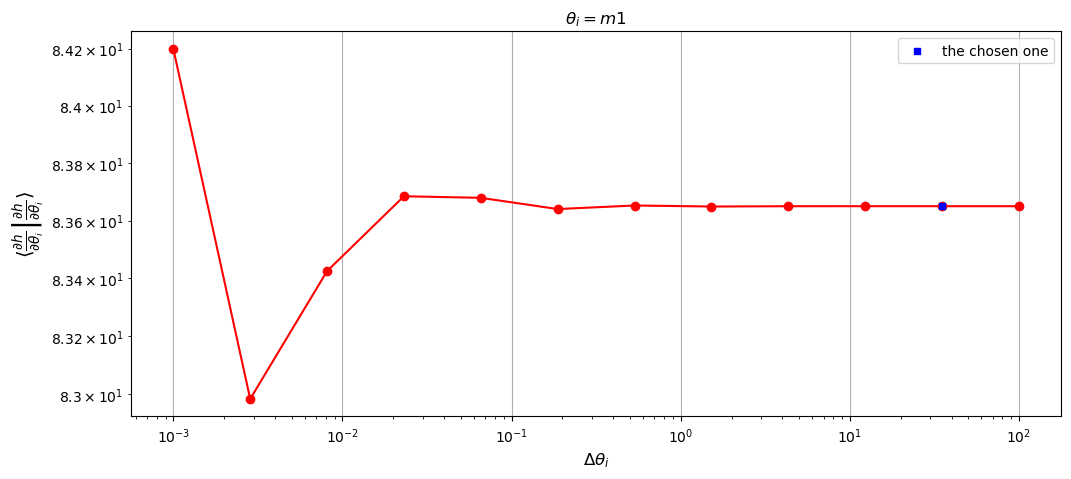

Gamma_ii for m2: 3399465014.6666446
Gamma_ii for m2: 3399471431.493853
Gamma_ii for m2: 3399536217.9908323
Gamma_ii for m2: 3399517516.783543
Gamma_ii for m2: 3399425117.988699
Gamma_ii for m2: 3400159443.3731647
Gamma_ii for m2: 3394553979.898539
Gamma_ii for m2: 3414757073.162479
Gamma_ii for m2: 3417870918.120618
Gamma_ii for m2: 3275807776.2560053
Gamma_ii for m2: 3043023768.2360935
Gamma_ii for m2: 3660385587.973961
[np.float64(1.8875955682613846e-06), np.float64(1.90574516124809e-05), np.float64(5.5011357337887965e-06), np.float64(2.718071192543848e-05), np.float64(0.00021596792641500337), np.float64(0.0016513107488699092), np.float64(0.005916407179509652), np.float64(0.0009110481445130615), np.float64(0.04336736205778831), np.float64(0.07649759770192212), np.float64(0.16866032413803153)]
0


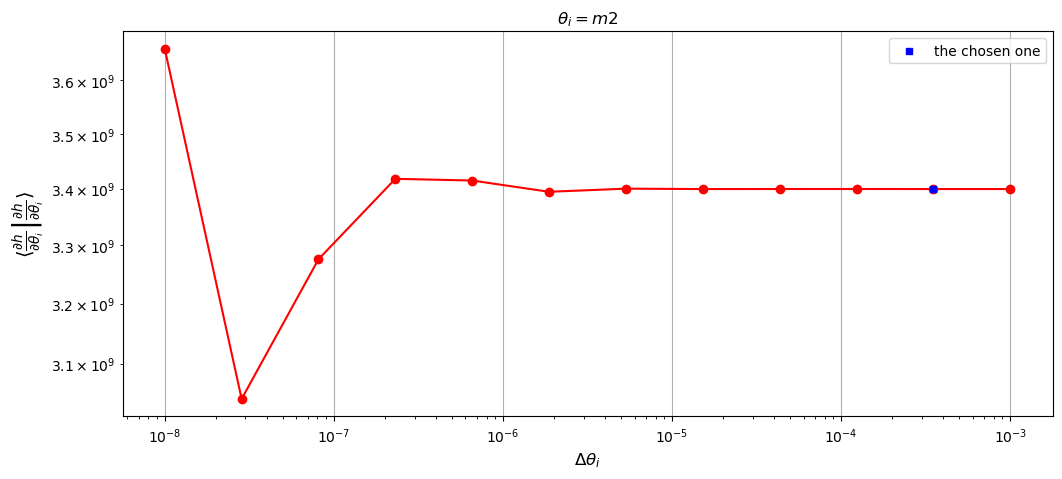

Gamma_ii for a: 245245698746.0348
Gamma_ii for a: 245246045017.38446
Gamma_ii for a: 245244183516.79596
Gamma_ii for a: 245246648629.43427
Gamma_ii for a: 245243645131.94598
Gamma_ii for a: 245228860994.86182
Gamma_ii for a: 245395979816.3564
Gamma_ii for a: 244946852940.1891
Gamma_ii for a: 244993072693.96848
Gamma_ii for a: 243402661528.84134
Gamma_ii for a: 216402813353.64624
Gamma_ii for a: 273550113534.12366
[np.float64(1.4119344907106021e-06), np.float64(7.590396484871122e-06), np.float64(1.0051565034963758e-05), np.float64(1.2246994154182092e-05), np.float64(6.0287100890939775e-05), np.float64(0.0006810169490945319), np.float64(0.0018335686732705045), np.float64(0.00018865739047700967), np.float64(0.00653407466926439), np.float64(0.12476662274751416), np.float64(0.20890980245690394)]
0


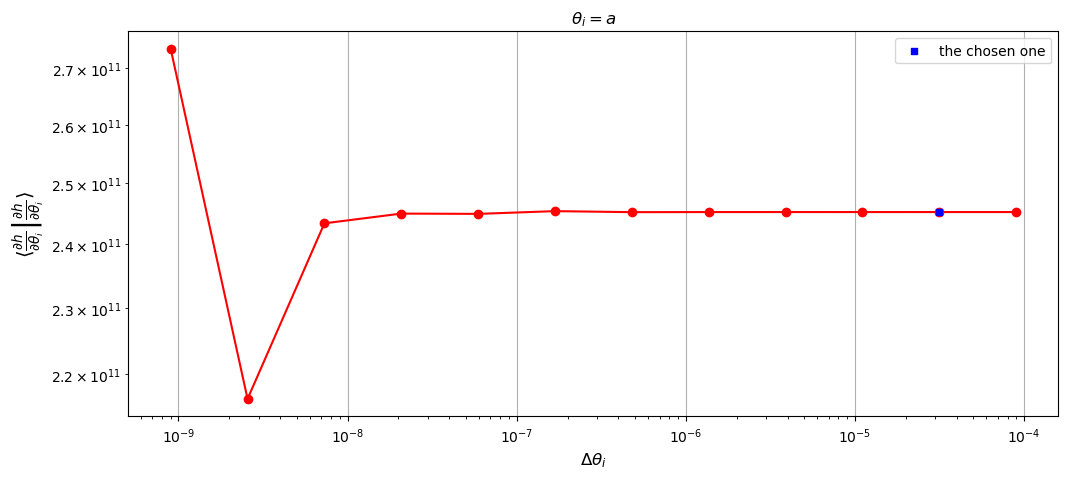

Gamma_ii for p0: 3425209444092.881
Gamma_ii for p0: 3425208500714.5044
Gamma_ii for p0: 3425209376980.659
Gamma_ii for p0: 3425208428948.6714
Gamma_ii for p0: 3425213575694.262
Gamma_ii for p0: 3425389030321.0547
Gamma_ii for p0: 3425265915139.2993
Gamma_ii for p0: 3426159084361.55
Gamma_ii for p0: 3423965988451.375
Gamma_ii for p0: 3427858616578.599
Gamma_ii for p0: 3437303818620.076
Gamma_ii for p0: 3432839874112.842
[np.float64(2.754221753998489e-07), np.float64(2.5582849348543757e-07), np.float64(2.767808171264942e-07), np.float64(1.5026057432862738e-06), np.float64(5.1221810205901043e-05), np.float64(3.594324785448496e-05), np.float64(0.0002606911121924528), np.float64(0.0006405133455098132), np.float64(0.001135585962734197), np.float64(0.0027478519618521465), np.float64(0.0013003649080451224)]
1


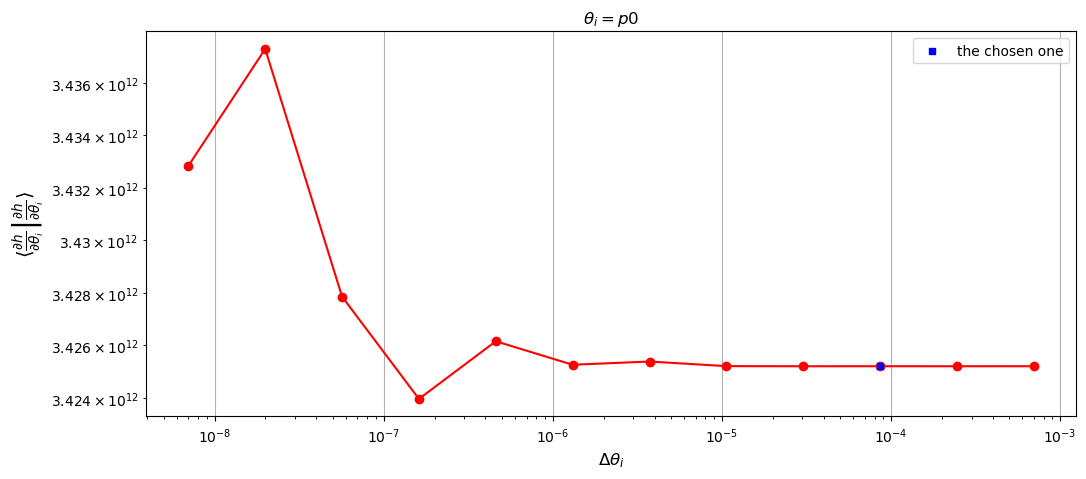

Gamma_ii for e0: 64364089821498.484
Gamma_ii for e0: 64364083689278.36
Gamma_ii for e0: 64364462189311.625
Gamma_ii for e0: 64364300777232.88
Gamma_ii for e0: 64365859961748.27
Gamma_ii for e0: 64361193589707.56
Gamma_ii for e0: 64376630309040.72
Gamma_ii for e0: 64413601833767.85
Gamma_ii for e0: 64383883525400.73
Gamma_ii for e0: 64439495232021.37
Gamma_ii for e0: 64480573347509.69
Gamma_ii for e0: 65349867771186.99
[np.float64(9.527394431036533e-08), np.float64(5.880574782903706e-06), np.float64(2.5077888952890267e-06), np.float64(2.4223781307625292e-05), np.float64(7.250288225632237e-05), np.float64(0.00023978762571218949), np.float64(0.0005739707713061165), np.float64(0.00046157992870064345), np.float64(0.0008630065524319312), np.float64(0.0006370618832269859), np.float64(0.013302160407133676)]
0


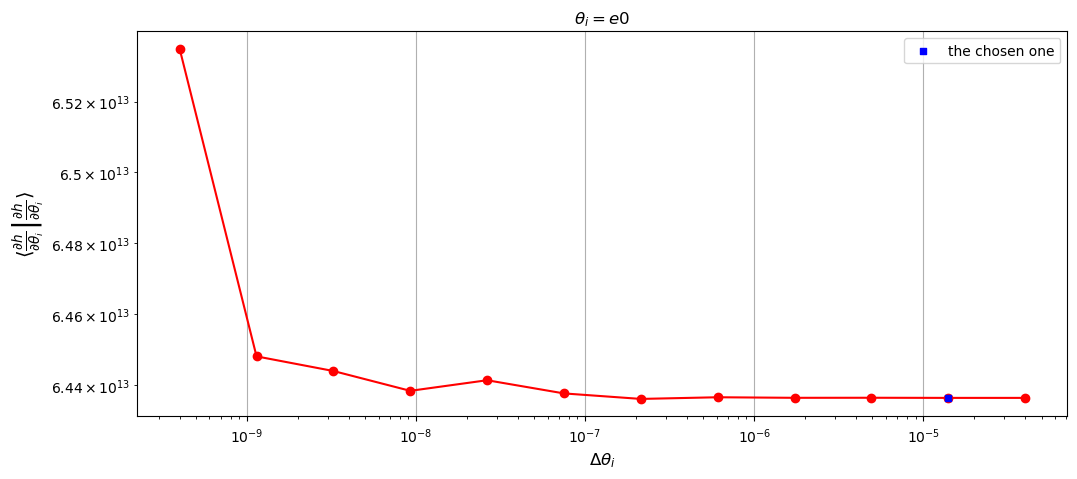

Gamma_ii for qS: 7127.580538711332
Gamma_ii for qS: 7127.581145360938
Gamma_ii for qS: 7127.581146510853
Gamma_ii for qS: 7127.5811465129955
Gamma_ii for qS: 7127.581146512835
Gamma_ii for qS: 7127.581146514088
Gamma_ii for qS: 7127.581146512794
Gamma_ii for qS: 7127.581146517555
Gamma_ii for qS: 7127.581146507139
Gamma_ii for qS: 7127.581146637513
Gamma_ii for qS: 7127.581146718621
Gamma_ii for qS: 7127.581146613249
[np.float64(8.511297071418913e-08), np.float64(1.6133314445336172e-10), np.float64(3.006306730615504e-13), np.float64(2.2457978972340433e-14), np.float64(1.7570816502788262e-13), np.float64(1.8157786407750355e-13), np.float64(6.679972722734336e-13), np.float64(1.4612998590423192e-12), np.float64(1.8291385861885066e-11), np.float64(1.1379560026678951e-11), np.float64(1.4783730271254328e-11)]
3


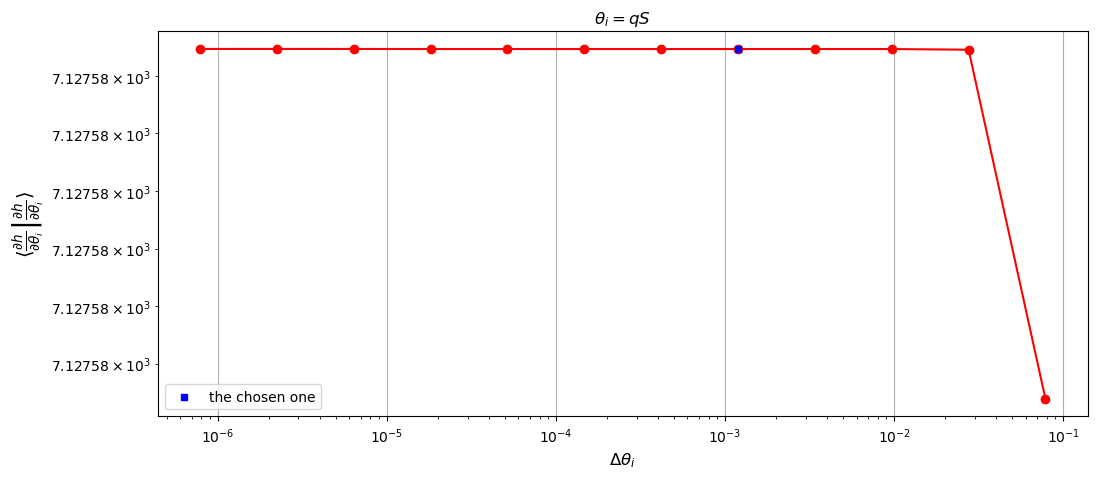

Gamma_ii for phiS: 137634.58756454583
Gamma_ii for phiS: 137634.58747059535
Gamma_ii for phiS: 137634.58747041566
Gamma_ii for phiS: 137634.58747041528
Gamma_ii for phiS: 137634.58747041528
Gamma_ii for phiS: 137634.58747041528
Gamma_ii for phiS: 137634.58747041534
Gamma_ii for phiS: 137634.58747041528
Gamma_ii for phiS: 137634.5874704157
Gamma_ii for phiS: 137634.58747041598
Gamma_ii for phiS: 137634.5874704131
Gamma_ii for phiS: 137634.58747041822
[np.float64(6.826080876733134e-10), np.float64(1.3055370204709432e-12), np.float64(2.7489441636090557e-15), np.float64(0.0), np.float64(0.0), np.float64(4.2291448670908533e-16), np.float64(4.229144867090855e-16), np.float64(2.9604014069635895e-15), np.float64(2.1145724335454165e-15), np.float64(2.0934267092100063e-14), np.float64(3.7216474830398725e-14)]
3


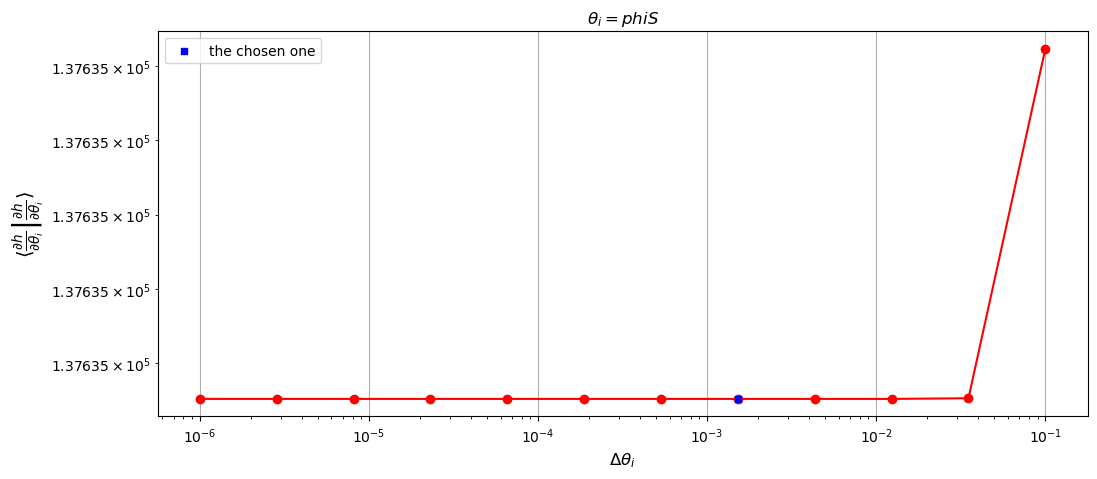

Gamma_ii for dev1p: 141830537502.5376
Gamma_ii for dev1p: 141830809583.4874
Gamma_ii for dev1p: 141835716235.12012
Gamma_ii for dev1p: 141835541557.03586
Gamma_ii for dev1p: 141830798456.89224
Gamma_ii for dev1p: 141756345548.6016
Gamma_ii for dev1p: 141953257614.30112
Gamma_ii for dev1p: 141685716718.64444
Gamma_ii for dev1p: 144297425259.87753
Gamma_ii for dev1p: 151113759456.8935
Gamma_ii for dev1p: 134490117490.44098
Gamma_ii for dev1p: 110389552381.60101
[np.float64(1.918348704330183e-06), np.float64(3.4593907394856904e-05), np.float64(1.2315536877531538e-06), np.float64(3.3441961796875386e-05), np.float64(0.0005252174638286157), np.float64(0.001387161302310867), np.float64(0.00188827005186382), np.float64(0.01809948123834812), np.float64(0.04510730340846546), np.float64(0.12360493303631813), np.float64(0.2183228810053304)]
2


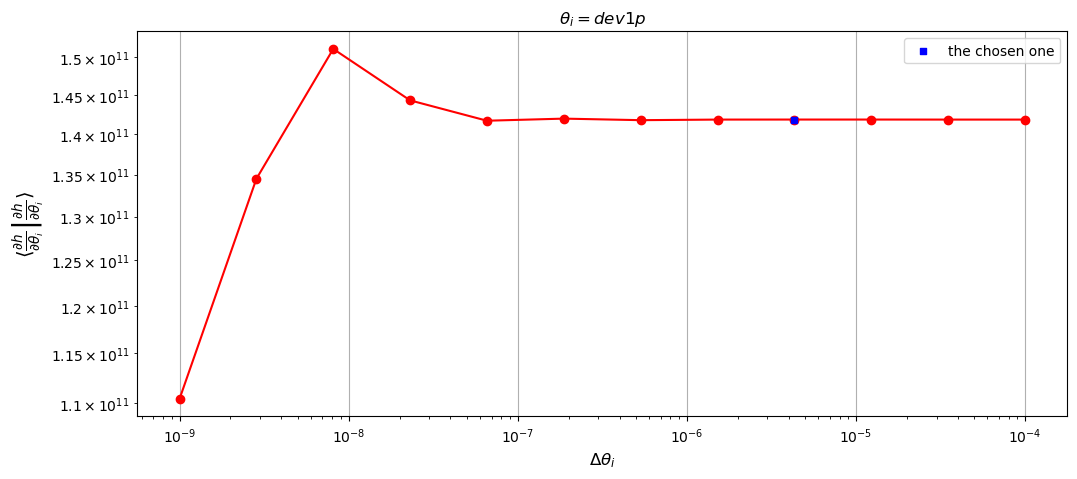

Gamma_ii for dev1e: 54327709121.26887
Gamma_ii for dev1e: 54327909785.294075
Gamma_ii for dev1e: 54324414641.21224
Gamma_ii for dev1e: 54329317324.54473
Gamma_ii for dev1e: 54317923976.91787
Gamma_ii for dev1e: 54358177706.62321
Gamma_ii for dev1e: 54389017433.754524
Gamma_ii for dev1e: 54317370897.213234
Gamma_ii for dev1e: 52713533459.18886
Gamma_ii for dev1e: 54994098479.688416
Gamma_ii for dev1e: 47473382546.80371
Gamma_ii for dev1e: 102797615415.98862
[np.float64(3.693571609888016e-06), np.float64(6.433836618243757e-05), np.float64(9.024010559900952e-05), np.float64(0.00020975300218953726), np.float64(0.0007405275784370685), np.float64(0.0005670212220487294), np.float64(0.0013190354274854295), np.float64(0.030425534635542442), np.float64(0.04146926822233233), np.float64(0.15841963494954414), np.float64(0.538185955435889)]
0


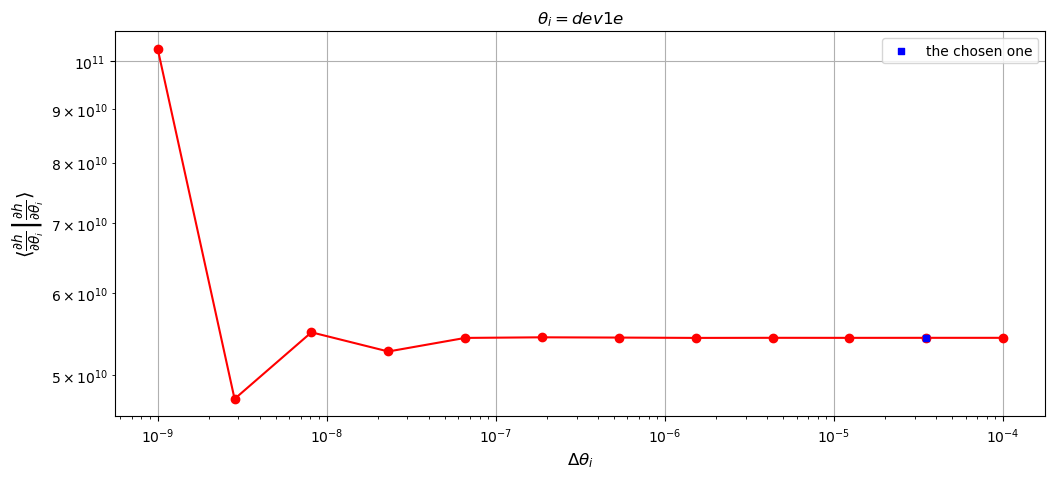

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 3.160072560793623e-05, 'p0': 8.629927176094463e-05, 'e0': 1.4044766936860542e-05, 'qS': 0.0011937353730786609, 'phiS': 0.0015199110829529332, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev1p': 4.328761281083061e-06, 'dev1e': 3.511191734215135e-05}
Time taken to compute stable deltas is 217.13991904258728 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 30.764261960983276 seconds


In [4]:
der_order = 6
Ndelta = 12
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    qS = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    # qK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
)

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
          #   delta_range = delta_range,
            live_dangerously = False)

In [6]:
from stableemrifisher.utils import fishinv
J = np.eye(len(Fisher))
J[0,0] = m1
Fisher_lnM = J.T @ Fisher @ J
Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)
Fisher_inv = J.T @ Fisher_lnM_inv @ J
pd.DataFrame(np.matmul(Fisher_lnM,Fisher_lnM_inv))



,0,1,2,3,4,5,6,7,8,9,10
0,1.000002e+00,3.763883e-06,5.190599e-07,-2.175181e-06,-3.782986e-07,-2.427309e-07,-2.219009e-08,1.022971e-06,5.058759e-06,-2.465089e-07,2.693188e-07
1,4.634015e-09,1.000000e+00,6.683583e-09,-1.643878e-08,3.438850e-09,-2.358535e-09,-1.487759e-09,1.167578e-08,-3.584972e-08,2.115779e-09,-5.568219e-09
2,7.447384e-10,5.023002e-08,1.000000e+00,-3.152168e-07,-2.621963e-08,3.819367e-09,5.448746e-10,-4.091294e-08,-2.190966e-08,-7.252854e-08,1.318324e-08
3,5.135262e-07,1.062685e-06,5.907664e-07,9.999967e-01,-2.020039e-07,-1.390085e-07,-4.020376e-08,2.454785e-07,-1.761353e-08,-2.063334e-07,8.189471e-08
4,-1.338617e-06,4.793744e-06,-3.297465e-07,-8.776891e-06,9.999990e-01,-6.863757e-07,-5.634436e-08,4.728690e-07,-1.499726e-06,-1.601976e-06,-4.114970e-07
5,-3.697752e-11,-2.632096e-11,-4.325835e-12,4.543665e-11,7.567294e-12,1.000000e+00,1.039123e-12,-2.694275e-12,-1.087160e-11,1.777740e-11,9.483840e-14
6,3.476271e-11,1.847538e-10,4.928687e-11,5.549833e-11,-2.470316e-12,-3.239973e-11,1.000000e+00,-3.426894e-11,-5.065989e-11,-9.797283e-11,2.015592e-11
7,-1.413965e-11,-9.545914e-11,-3.135646e-11,8.295619e-11,6.094462e-12,5.148093e-12,-1.940962e-12,1.000000e+00,-3.952650e-11,5.250587e-12,1.790696e-12
8,4.132477e-12,-6.066572e-12,-1.060924e-11,-6.537460e-11,4.028278e-12,8.260384e-12,-4.916812e-13,9.816140e-12,1.000000e+00,5.068106e-12,-1.576538e-12
9,1.586320e-07,3.654094e-07,1.001139e-07,-9.015705e-07,-3.106828e-08,-6.820123e-08,-1.164059e-08,3.161583e-08,9.699218e-08,9.999999e-01,-5.497762e-09


In [7]:
print(np.linalg.cond(Fisher_lnM))
np.sum(np.matmul(Fisher_lnM,Fisher_lnM_inv))

6290756749184.55


np.float64(10.999996495958305)

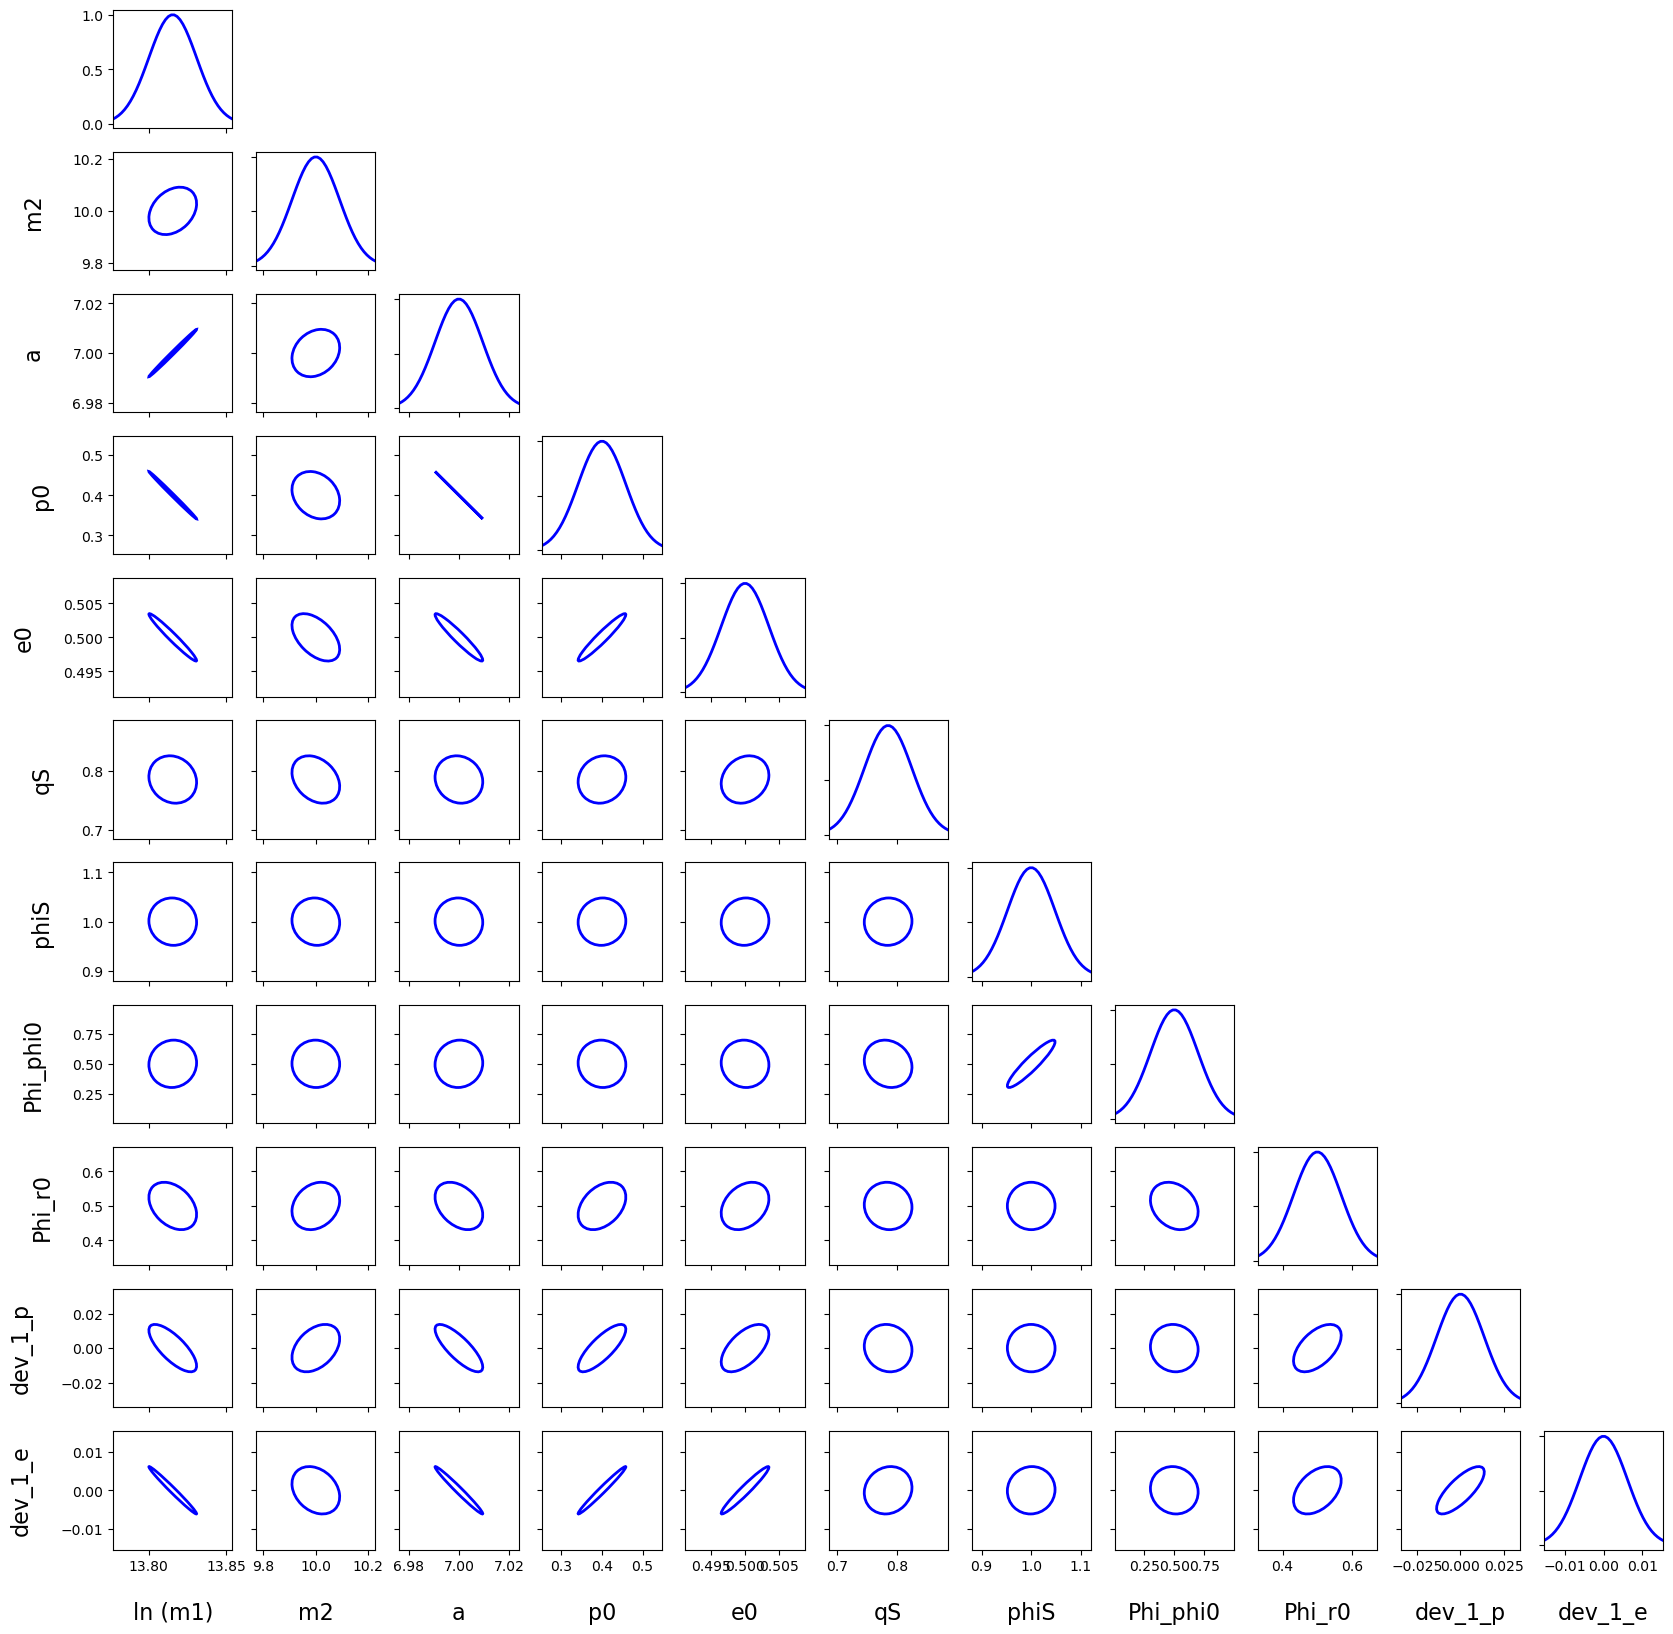

In [8]:

from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [np.log(m1), m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,dev_1_p,dev_1_e]
param_names = ["ln (m1)",'m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"dev_1_p","dev_1_e"]
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
param_names = param_names

covariance = Fisher_lnM_inv

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)


In [9]:

pd.DataFrame(covariance).to_csv(
    "../covariance_dev_b.csv")


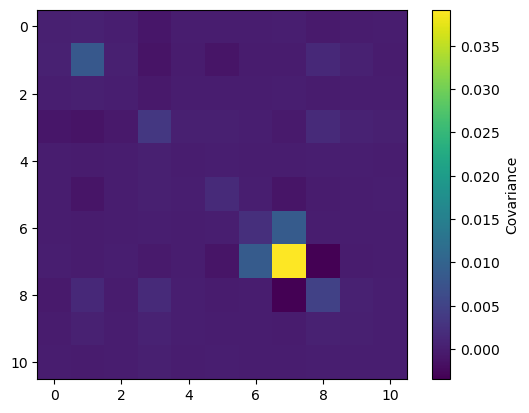

In [10]:

plt.imshow(covariance[0:][0:], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Covariance')



      0         1         2         3         4         5         6   \
0    0.0  0.000310 -0.000267  0.000172 -0.001072 -0.000089  0.000037   
1    1.0 -0.000267  0.012782 -0.000148  0.000925  0.000076 -0.001751   
2    2.0  0.000172 -0.000148  0.000095 -0.000593 -0.000049  0.000020   
3    3.0 -0.001072  0.000925 -0.000593  0.003706  0.000308 -0.000127   
4    4.0 -0.000089  0.000076 -0.000049  0.000308  0.000026 -0.000011   
5    5.0  0.000037 -0.001751  0.000020 -0.000127 -0.000011  0.001699   
6    6.0 -0.000005 -0.000368 -0.000003  0.000016  0.000001  0.000062   
7    7.0  0.000006  0.000067 -0.000009  0.000057 -0.000016 -0.001155   
8    8.0  0.000078 -0.000121  0.000051 -0.000320 -0.000013  0.000004   
9    9.0  0.000285 -0.001500  0.000158 -0.000985 -0.000082  0.000206   
10  10.0  0.000487 -0.001671  0.000269 -0.001679 -0.000141  0.000230   

          7         8         9         10        11  
0  -0.000005  0.000006  0.000078  0.000285  0.000487  
1  -0.000368  0.000067 -0

/Users/rishavagrawal/programs/StableEMRIFisher/stableemrifisher/plot.py:47: RuntimeWarning: invalid value encountered in divide
  return np.exp(-(mean-x)**2/var/2)
/Users/rishavagrawal/programs/StableEMRIFisher/stableemrifisher/plot.py:92: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axs[j,i].set_xlim([mean - 2.5*np.sqrt(covariance[i][i]), mean + 2.5*np.sqrt(covariance[i][i])])
/Users/rishavagrawal/programs/StableEMRIFisher/stableemrifisher/plot.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
/Users/rishavagrawal/programs/StableEMRIFisher/stableemrifisher/plot.py:24: RuntimeWarning: invalid value encountered in sqrt
  ell_radius_x = np.sqrt(1 + pearson)
/Users/rishavagrawal/programs/StableEMRIFisher/stableemrifisher/plot.py:35: RuntimeWarning: invalid value encountered in sqrt
  scale_y = np.sqrt(cov[1, 1]) * n_std
/opt/homebrew/Caskroom/min

ValueError: Axis limits cannot be NaN or Inf

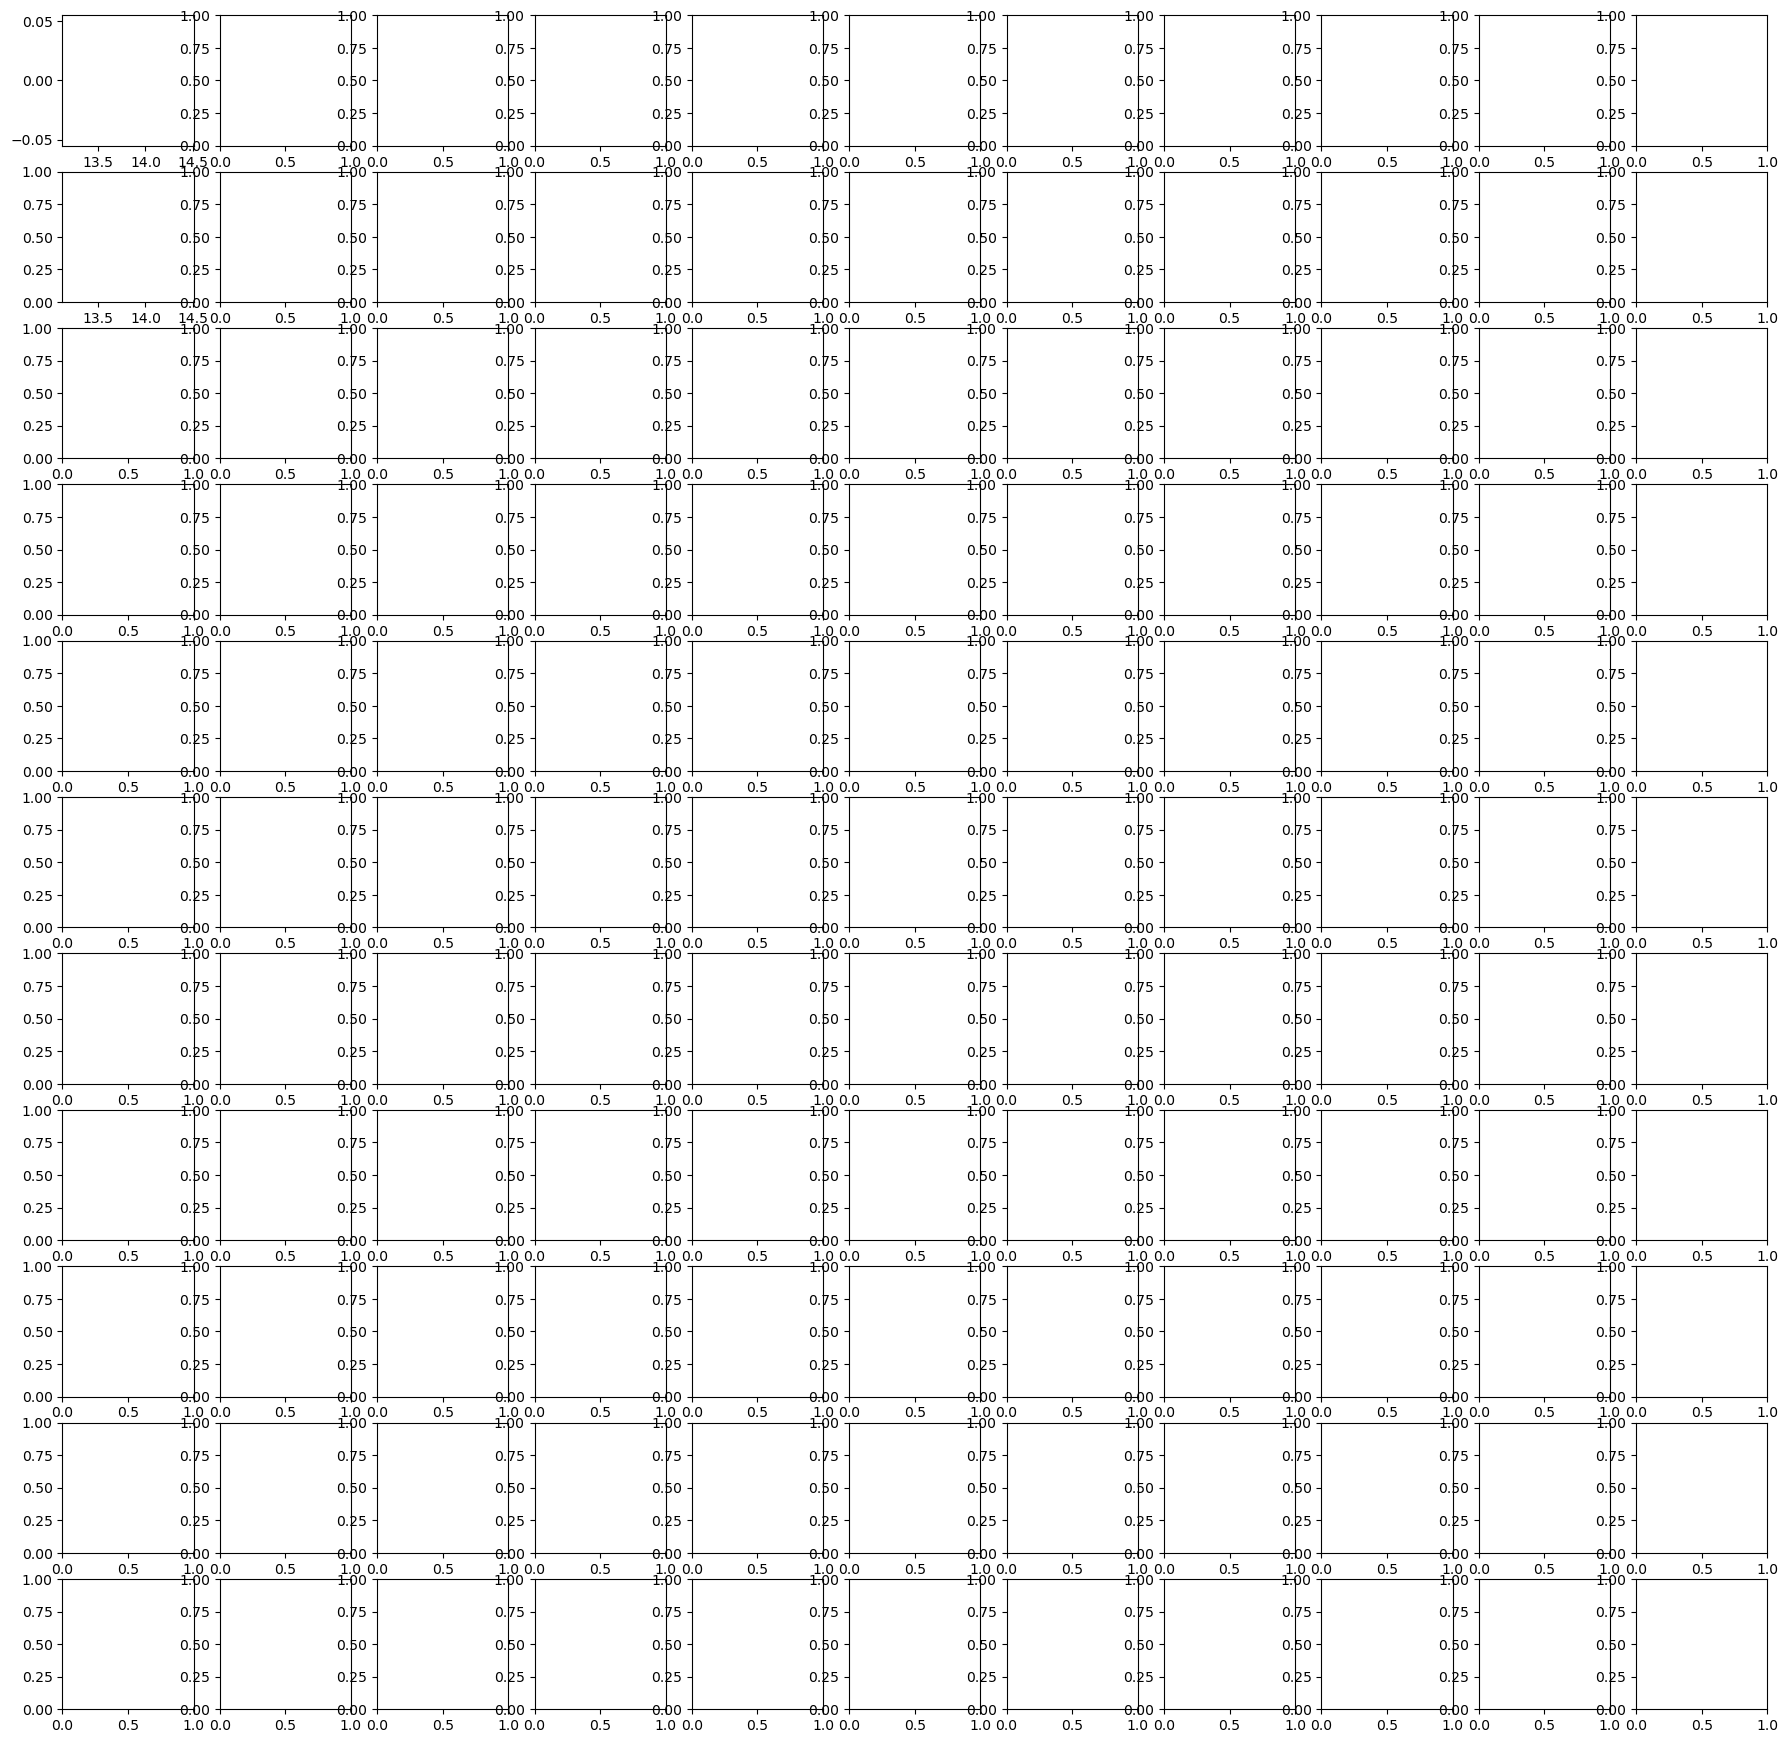

In [15]:

import matplotlib.pyplot as plt
from stableemrifisher.plot import CovEllipsePlot
dev_0_p, dev_0_e, dev_1_p, dev_1_e=0.0,0.0,0.0,0.0
Covariance_fisher_dev_a=np.loadtxt("../covariance_dev_a.csv", delimiter=",", skiprows=1,dtype=np.float64)
print(pd.DataFrame(Covariance_fisher_dev_a))
Covariance_fisher_dev_b=covariance
# Parameters
pars_list = [np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e]
param_names = ['ln (m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"dev_p","dev_e"]

wave_params = {param_names[i]: pars_list[i] for i in range(len(pars_list))}

ellipse_kwargs_unnorm = dict(facecolor='none', edgecolor='tab:blue', lw=2, label='dev_a (0th order)')
line_kwargs_unnorm = dict(lw=2, color='tab:blue')

ellipse_kwargs_norm = dict(facecolor='none', edgecolor='tab:orange', lw=2, label='dev_b (1st order)')
line_kwargs_norm = dict(lw=2, color='tab:orange')

n_params = len(param_names)
fig, axs = plt.subplots(n_params, n_params, figsize=(22, 22))
fig, axs = CovEllipsePlot(
    Covariance_fisher_dev_a,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_unnorm,
    line_kwargs=line_kwargs_unnorm
)

fig, axs = CovEllipsePlot(
    Covariance_fisher_dev_b,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_norm,
    line_kwargs=line_kwargs_norm
)

fig.suptitle("Covariance Ellipse Comparison: 0th order vs 1st order", fontsize=22, y=0.93)

for i in range(n_params):
    for j in range(n_params):
        axs[i, j].grid(True, linestyle='--', alpha=0.3)
        if i < n_params - 1:
            axs[i, j].set_xlabel('')
        if j > 0:
            axs[i, j].set_ylabel('')

for i, name in enumerate(param_names):
    axs[-1, i].set_xlabel(name, fontsize=13)
    axs[i, 0].set_ylabel(name, fontsize=13)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=3, label='covariance dev_a'),
    Line2D([0], [0], color='tab:orange', lw=3, label='covariance dev_b')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.98, 0.98)
)

plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()

